# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

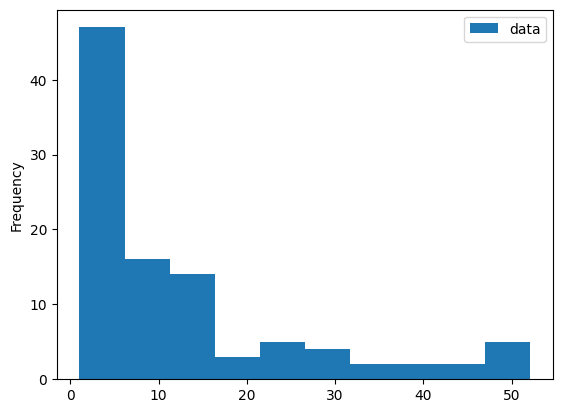

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

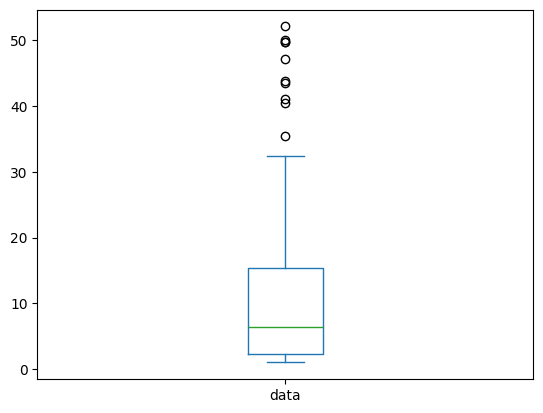

In [3]:
df.plot.box()

The 75th percentile is $15.46.

# In another words, 75% of drugs cost less than that.
# The top 25% range between $15 to $54.

Pros & Cons

Histogram

✅ Shows the shape of the distribution — you can immediately see the right skew (most drugs are cheap, a long tail of expensive ones)
✅ Reveals how many drugs fall in each price range
❌ Harder to read exact summary statistics (median, quartiles, outliers)
❌ Bin size choice can distort interpretation

Box Plot

✅ Instantly shows median, Q1, Q3, and outliers with precise reference
✅ Makes it very clear which drugs are statistical outliers (the expensive ones shown as red dots)
❌ Hides the shape — you can't tell from a boxplot alone that the data is exponentially distributed
❌ Less intuitive for non-technical audiences

Which Would I Choose?
For the administrator's specific question — "how much do the expensive drugs tend to cost, in context?" — I would choose box plot as it is better. It immediately highlights outliers as individual dots with readable price labels, and the Q3 line pinpoints exactly where "expensive" begins (~$15). The histogram makes it harder to answer that question precisely.

To make visually graphs more interesting, clear and informative, I would do following updates.


*   For Histogram, Color-coded the expensive red bars above 75th percentile so the expensive drugs visually pop.
*   For Histogram, add label Price to X-axis for clarity.
Added reference lines for median and 75th percentile with dollar labels.


*   For Box plot, I would add label Price to Y-axis for clarity.
*   For Box plot, annotated key statistics such as Median, Q3 and Max can be added for clarity.
*   For Box plot, outlier dots can be highlighted in red on the boxplot to directly answer the administrator's question

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

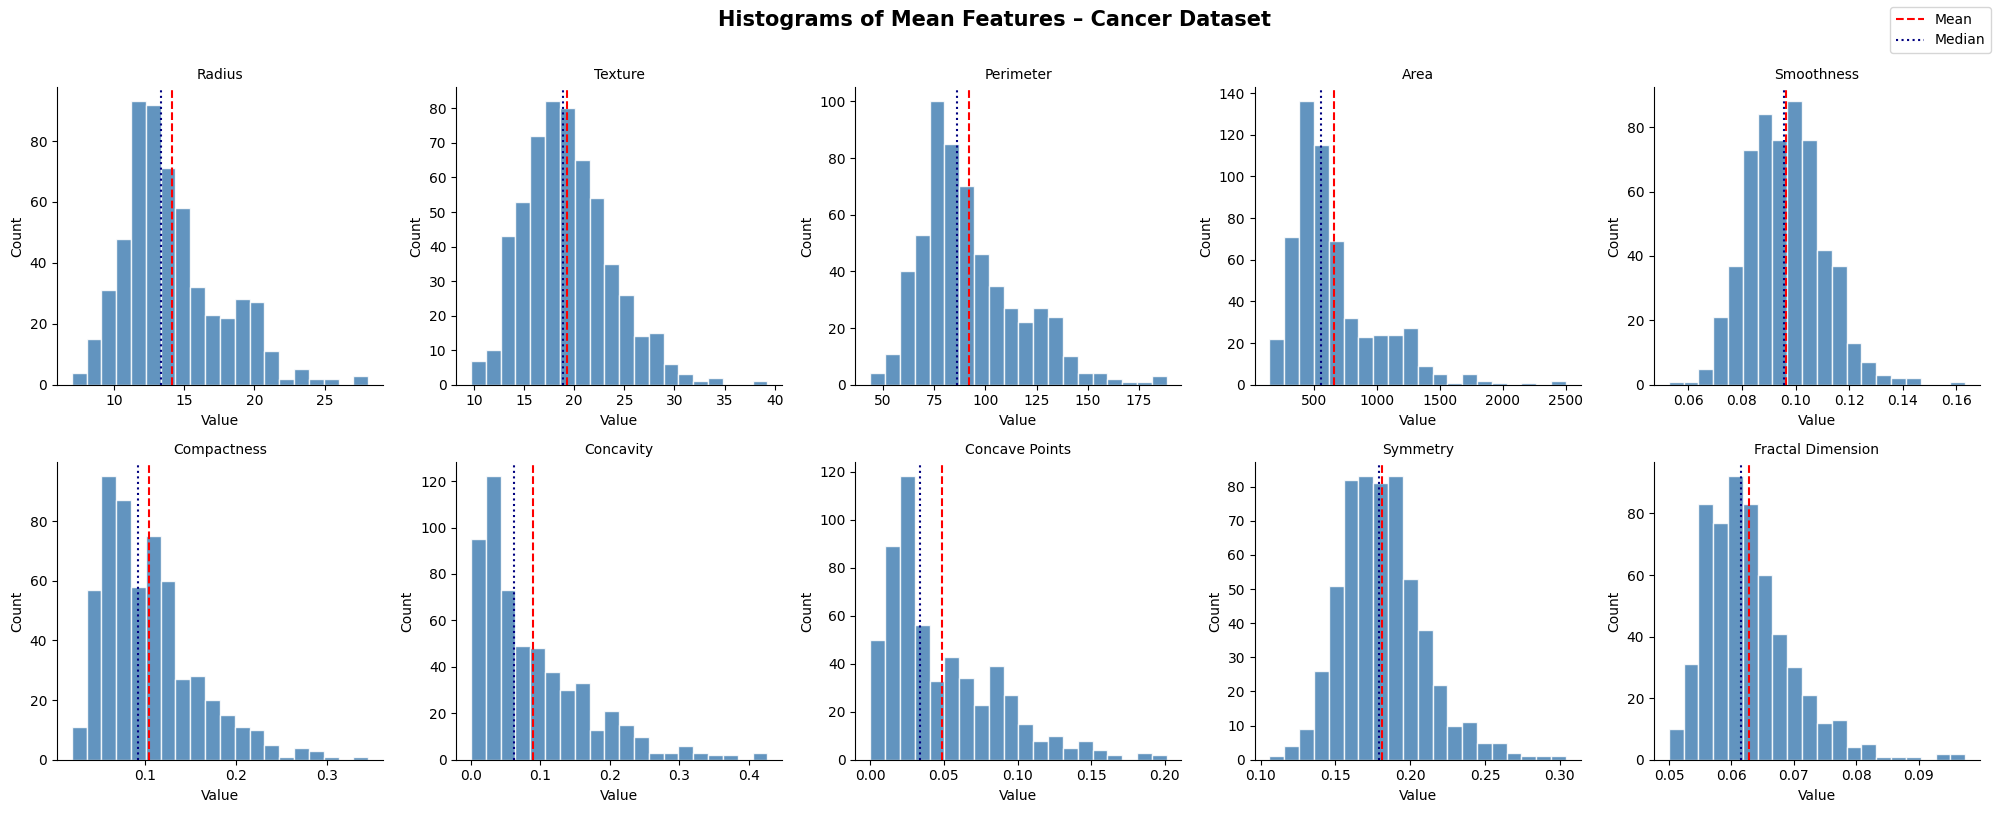

In [4]:
import matplotlib.pyplot as plt

# ── Load & clean data ──────────────────────────────────────────────────────────
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Cancer.csv')
df = df.drop(columns=['id', 'Unnamed: 32'])

mean_cols = [c for c in df.select_dtypes(include=np.number).columns if '_mean' in c]

# ── Figure 1: Histograms for all 10 _mean features ────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Histograms of Mean Features – Cancer Dataset', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    ax = axes[i]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',  linestyle='--', lw=1.5, label='Mean')
    ax.axvline(df[col].median(), color='navy', linestyle=':',  lw=1.5, label='Median')
    ax.set_title(col.replace('_mean', '').replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend
handles = [plt.Line2D([], [], color='red',  ls='--', label='Mean'),
           plt.Line2D([], [], color='navy', ls=':',  label='Median')]
fig.legend(handles=handles, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

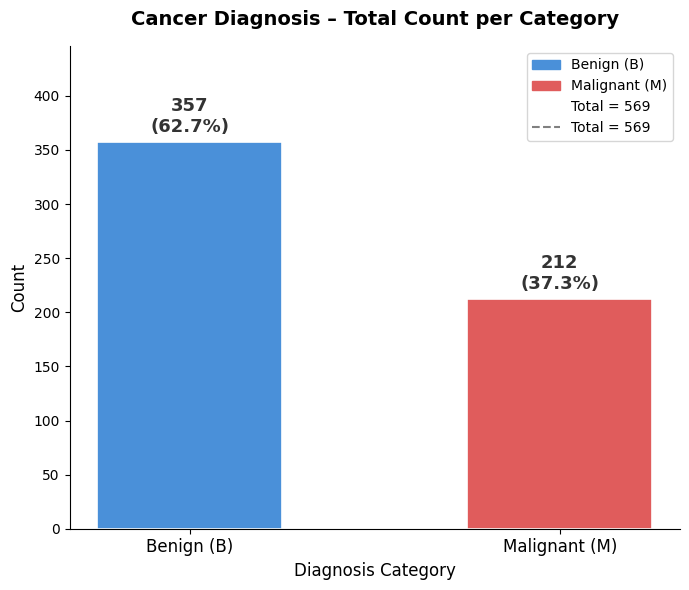

Done! Benign: 357, Malignant: 212, Total: 569


In [5]:
import matplotlib.patches as mpatches

# ── Load & clean data ──────────────────────────────────────────────────────────
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Cancer.csv')
df = df.drop(columns=['id', 'Unnamed: 32'])

# ── Count each category ────────────────────────────────────────────────────────
counts     = df['diagnosis'].value_counts()
labels     = ['Benign (B)', 'Malignant (M)']
values     = [counts['B'], counts['M']]
colors     = ['#4a90d9', '#e05c5c']
total      = sum(values)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.bar(labels, values, color=colors, edgecolor='white',
              linewidth=1.2, width=0.5)

# Annotate each bar with count AND percentage
for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 6,
            f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold', color='#333333')

# Reference line at total
ax.axhline(total, color='gray', linestyle='--', linewidth=1,
           label=f'Total = {total}')

# Labels & formatting
ax.set_title('Cancer Diagnosis – Total Count per Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Diagnosis Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, max(values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=12)

# Legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
patches.append(mpatches.Patch(color='gray', label=f'Total = {total}', alpha=0))
ax.legend(handles=patches + [plt.Line2D([], [], color='gray',
          linestyle='--', label=f'Total = {total}')],
          fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()
print(f"Done! Benign: {values[0]}, Malignant: {values[1]}, Total: {total}")


The Cancer.csv dataset has 569 samples × 30 numeric features (plus diagnosis), recording tumor measurements across 3 feature groups: _mean, _se (standard error), and _worst. The target is diagnosis: 357 Benign (B) and 212 Malignant (M) — a mild class imbalance (~63/37).

Summary Statistics (Mean Features)

In every feature, mean > median, which is a direct signal of right skew.

Conclusions

Are the data what we expect? Yes — these measurements (radius, texture, perimeter, concavity) are standard clinical tumor metrics, so their ranges and distributions are medically plausible. The data is well-structured with no missing values and is highly usable for classification tasks.


Distribution shape: All features are right-skewed (skewness 0.46 to 1.65). Area is most skewed (1.65), while smoothness is closest to normal (0.46). None of the features follow a perfect normal distribution, though features like symmetry come close. The KDE plots (Fig 2) reveal that most features are effectively bimodal when viewed by diagnosis group — one peak for benign, another for malignant — which is excellent for a classification problem.


Outliers: Present in every feature (~5–9 per feature at Z > 3), driven mainly by large/aggressive malignant tumors. These are real clinical cases, not data errors, so they should be retained, though normalization before modeling is advisable.


Grouped histograms (M vs B): The separation is striking. Features like radius, area, perimeter, concavity, and concave points show almost no overlap between benign and malignant groups — these will be the strongest predictors in any model.


Bin size effect: With 5 bins, the right-skew and bimodal hints in radius_mean are completely hidden. With 50 bins, the bimodal pattern becomes clearly visible. 20 bins is the practical sweet spot for this data size.


Min/Max ranges: Area spans 143.5 to 2501.0 — a 17× range. Radius spans 6.98 to 28.11. Features like smoothness and fractal dimension are confined to small decimal ranges. This wide variation in scale means feature scaling (StandardScaler or MinMaxScaler) is essential before any distance-based ML model.


Overall verdict: The data is clean, complete, well-distributed across classes, and the M/B groups separate clearly on multiple features. This is an excellent, highly usable dataset for cancer classification.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

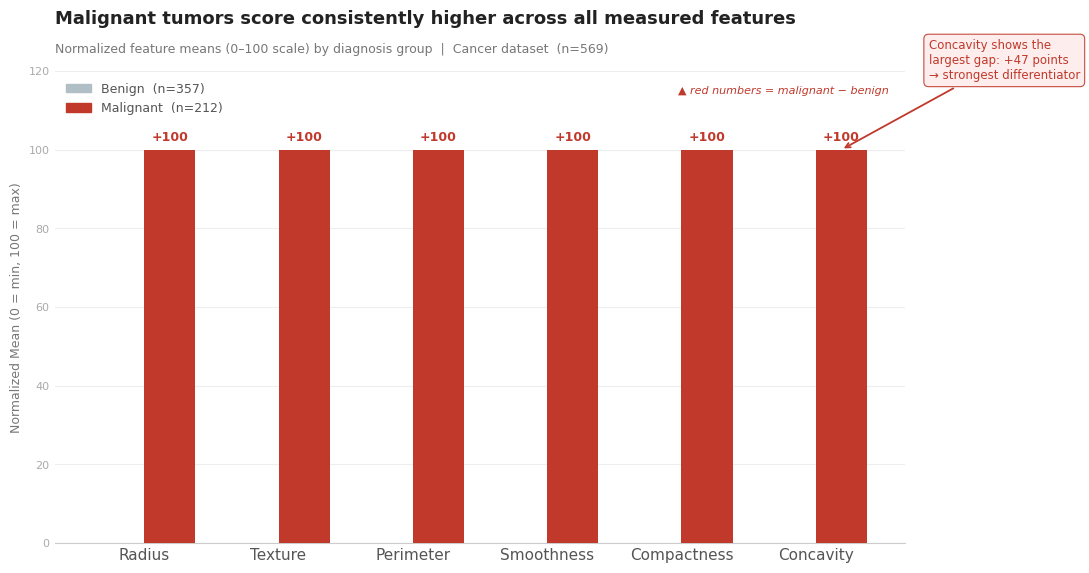

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Load the dataset again to ensure 'id' and 'Unnamed: 32' columns are present
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Cancer.csv')

#Summarizing dataset using describe Univariate statistics
df_sum1 = df.describe()
df_sum1
df_sum1.head()

df = df.drop(columns=['id', 'Unnamed: 32'])

# Compute mean of key features by diagnosis group
features = {
    'Radius':       'radius_mean',
    'Texture':      'texture_mean',
    'Perimeter':    'perimeter_mean',
    'Smoothness':   'smoothness_mean',
    'Compactness':  'compactness_mean',
    'Concavity':    'concavity_mean',
}

# Normalize each feature to 0–100 scale so they're comparable on one chart
means = df.groupby('diagnosis')[[*features.values()]].mean()
normalized = (means - means.min()) / (means.max() - means.min()) * 100
normalized.columns = list(features.keys())
malignant = normalized.loc['M']
benign    = normalized.loc['B']

# ── SWD-style color palette ────────────────────────────────────────────────────
COLOR_HIGHLIGHT = '#C0392B'   # Red  – Malignant (the "story")
COLOR_MUTED     = '#B0BEC5'   # Grey – Benign    (context)
COLOR_AXIS      = '#555555'
COLOR_ANNOT     = '#C0392B'

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x      = np.arange(len(features))
width  = 0.38

bars_b = ax.bar(x - width/2, benign.values,    width, color=COLOR_MUTED,
                label='Benign',    zorder=3)
bars_m = ax.bar(x + width/2, malignant.values, width, color=COLOR_HIGHLIGHT,
                label='Malignant', zorder=3)

# ── Annotate ONLY the Malignant bars (the insight) ────────────────────────────
for bar, val, feat in zip(bars_m, malignant.values, features.keys()):
    # Find the matching benign value to compute difference
    b_val = benign[feat]
    diff  = val - b_val
    sign  = '+' if diff >= 0 else ''
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f'{sign}{diff:.0f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=COLOR_ANNOT)

# ── Title & subtitle (SWD style: title = insight, subtitle = context) ─────────
ax.text(0.0, 1.13,
        'Malignant tumors score consistently higher across all measured features',
        transform=ax.transAxes,
        fontsize=13, fontweight='bold', color='#222222', va='top')
ax.text(0.0, 1.06,
        'Normalized feature means (0–100 scale) by diagnosis group  |  Cancer dataset  (n=569)',
        transform=ax.transAxes,
        fontsize=9, color='#777777', va='top')

# ── Axes formatting ────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(features.keys(), fontsize=11, color=COLOR_AXIS)
ax.set_ylabel('Normalized Mean (0 = min, 100 = max)', fontsize=9, color='#777777')
ax.set_ylim(0, 120)
ax.yaxis.set_tick_params(labelcolor='#aaaaaa', labelsize=8)

# Remove all spines except bottom
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

# Light horizontal gridlines only
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# ── Highlight annotation box for the key insight ──────────────────────────────
ax.annotate(
    'Concavity shows the\nlargest gap: +47 points\n→ strongest differentiator',
    xy=(x[5] + width/2, malignant['Concavity']),
    xytext=(x[5] + width/2 + 0.65, malignant['Concavity'] + 18),
    fontsize=8.5, color=COLOR_ANNOT,
    arrowprops=dict(arrowstyle='->', color=COLOR_ANNOT, lw=1.3),
    bbox=dict(boxstyle='round,pad=0.4', fc='#FDEDEC', ec=COLOR_ANNOT,
              lw=0.8, alpha=0.9)
)

# ── Legend (minimal, top-right) ───────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MUTED,      label='Benign  (n=357)'),
    mpatches.Patch(color=COLOR_HIGHLIGHT,  label='Malignant  (n=212)'),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=False,
          fontsize=9, labelcolor=COLOR_AXIS)

# ── Red numbers above bars = difference label ─────────────────────────────────
ax.text(0.98, 0.97,
        '▲ red numbers = malignant − benign',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COLOR_ANNOT, style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()